# 03 — Predict

**Changes applied:**
- CHANGE 4: DASFS validity check — full range `[p_fresh − 2σ, p_rotten + 2σ]`
- CHANGE 5: Fruit confidence gate (`FRUIT_CONF_THRESHOLD = 0.70`)
- CHANGE 6: Top-2 fallback with validity check
- Batch prediction block — predict every image in `test_img/` at once


In [1]:
import os, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import cv2
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
import tensorflow as tf

# ── CONFIG ────────────────────────────────────────────────────────────────────
PIPELINE_DIR         = "pipeline_v2"
TEST_FOLDER          = "test_img"          # folder used for batch prediction
FRUIT_CONF_THRESHOLD = 0.70               # CHANGE 5 — tune if needed
EXTS                 = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
# ─────────────────────────────────────────────────────────────────────────────


## Handcrafted extractor — must match `00_extract.ipynb` exactly

In [2]:
def _extract_handcrafted(img_bgr) -> np.ndarray:
    img = cv2.resize(img_bgr, (224, 224)).astype(np.float32)
    b, g, r = cv2.split(img)
    rgb = [r.mean(), g.mean(), b.mean(), r.std(), g.std(), b.std()]
    hsv = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2HSV)
    h, s, v = (hsv[:, :, i].astype(np.float32) for i in range(3))
    h_rad = h * (2 * np.pi / 180)
    cx, sx = np.cos(h_rad).mean(), np.sin(h_rad).mean()
    hsv_f = [float(np.arctan2(sx, cx)), float(s.mean()), float(v.mean()),
             float(np.sqrt(-2 * np.log(np.sqrt(cx**2 + sx**2) + 1e-6))),
             float(s.std()), float(v.std())]
    lab = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2LAB)
    L, a, b2 = (lab[:, :, i].astype(np.float32) for i in range(3))
    lab_f = [L.mean(), L.std(), a.mean(), a.std(), b2.mean(), b2.std()]
    gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_BGR2GRAY)
    lap  = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    glcm = graycomatrix((gray // 8).astype(np.uint8), [1], [0],
                        levels=32, symmetric=True, normed=True)
    hist, _ = np.histogram(gray, bins=256, range=(0, 255), density=True)
    tex_f = [lap,
             float(graycoprops(glcm, "contrast")[0, 0]),
             float(graycoprops(glcm, "energy")[0, 0]),
             float(graycoprops(glcm, "homogeneity")[0, 0]),
             float(entropy(hist + 1e-6))]
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        c = max(cnts, key=cv2.contourArea)
        area = float(cv2.contourArea(c)); peri = float(cv2.arcLength(c, True))
        hull_a = float(cv2.contourArea(cv2.convexHull(c)))
        x_, y_, w_, h_ = cv2.boundingRect(c)
        shp_f = [area, peri, 4 * np.pi * area / (peri * peri + 1e-6),
                 area / (hull_a + 1e-6), w_ / (h_ + 1e-6), area / (w_ * h_ + 1e-6)]
    else:
        shp_f = [0.0] * 6
    feats = rgb + hsv_f + lab_f + tex_f + shp_f + [float((gray < 50).mean())]
    assert len(feats) == 30, f"Handcrafted dim error: {len(feats)}"
    return np.array(feats, dtype=np.float32)


## Load models *(run once per session)*

In [3]:
print("[1/3] Loading models ...", end=" ", flush=True)
m = f"{PIPELINE_DIR}/models"
a = f"{PIPELINE_DIR}/artifacts"

global_scaler = joblib.load(f"{m}/scaler.pkl")
scaler_fruit  = joblib.load(f"{m}/scaler_fruit.pkl")
scaler_fresh  = joblib.load(f"{m}/scaler_fresh.pkl")
rfe_fruit     = joblib.load(f"{m}/rfe_fruit.pkl")
rfe_fresh     = joblib.load(f"{m}/rfe_fresh.pkl")
svm_fruit     = joblib.load(f"{m}/svm_fruit.pkl")
dasfs_dict    = joblib.load(f"{m}/dasfs.pkl")
knn_bundle    = joblib.load(f"{m}/knn_dict.pkl")
knn_dict      = knn_bundle["knn_dict"]
tau_dict      = knn_bundle["tau_dict"]
top300_idx    = np.load(f"{a}/top300_cmi.npy")
print("done")

print("[2/3] Loading EfficientNetB0 ...", end=" ", flush=True)
backbone   = tf.keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", pooling="avg")
preprocess = tf.keras.applications.efficientnet.preprocess_input
print("done")
print(f"[3/3] DASFS fruits : {sorted(dasfs_dict.keys())}")
print(f"      KNN   fruits : {sorted(knn_dict.keys())}")


[1/3] Loading models ... done
[2/3] Loading EfficientNetB0 ... done
[3/3] DASFS fruits : ['apple', 'banana', 'capsicum', 'carrot', 'cucumber', 'potato']
      KNN   fruits : ['apple', 'banana', 'capsicum', 'carrot', 'cucumber', 'potato']


## Predict helpers

| Function | Purpose |
|---|---|
| `_extract_features` | 1310-d vector from BGR image |
| `_freshness_for_fruit` | DASFS score + conf + KNN support for one fruit |
| `_valid_candidate` | **CHANGE 4** — full-range validity `[p_fresh−2σ, p_rotten+2σ]` |
| `_top2_fallback` | **CHANGE 6** — pick highest-confidence valid candidate |
| `predict` | **CHANGE 5** — confidence gate entry point |


In [4]:
def _extract_features(img_bgr: np.ndarray) -> np.ndarray:
    img_rgb = cv2.resize(img_bgr, (224, 224))
    emb     = backbone.predict(
        preprocess(np.expand_dims(img_rgb.astype(np.float32), 0)), verbose=0
    ).flatten()
    return np.concatenate([emb, _extract_handcrafted(img_bgr)])   # (1310,)


def _freshness_for_fruit(xf_vec: np.ndarray, fruit: str):
    # Return (dasfs_score, dasfs_conf, knn_sup, proj) or None.
    if fruit not in dasfs_dict or fruit not in knn_dict:
        return None
    d      = dasfs_dict[fruit]
    proj   = float(xf_vec @ d["axis"])
    p_f, p_r, sp = d["p_fresh"], d["p_rotten"], d["spread"]
    score  = float(np.clip((p_r - proj) / (p_r - p_f + 1e-8), 0.0, 1.0))
    mid    = (p_f + p_r) / 2.0
    d_conf = float(np.clip(
        1.0 - np.exp(-((proj - mid) ** 2) / (2.0 * sp ** 2 + 1e-8)), 0.0, 1.0))
    k_dist  = float(knn_dict[fruit].kneighbors(xf_vec.reshape(1, -1))[0].mean())
    knn_sup = float(np.exp(-k_dist / (tau_dict[fruit] + 1e-8)))
    return score, d_conf, knn_sup, proj


def _valid_candidate(fruit: str, proj: float) -> bool:
    # CHANGE 4 — full-range check
    # OLD: abs(proj - midpoint) <= 2*spread   ← rejects valid extreme-fresh/rotten
    # NEW: proj in [p_fresh - 2*spread, p_rotten + 2*spread]
    d = dasfs_dict[fruit]
    return (proj >= d["p_fresh"]  - 2 * d["spread"] and
            proj <= d["p_rotten"] + 2 * d["spread"])


def _top2_fallback(xf_vec: np.ndarray, probs: np.ndarray, classes) -> str:
    # CHANGE 6 — evaluate top-2 candidates, pick highest valid confidence
    candidates = [str(classes[i]) for i in np.argsort(probs)[::-1][:2]]
    best_fruit, best_conf = None, -1.0
    for cand in candidates:
        res = _freshness_for_fruit(xf_vec, cand)
        if res is None:
            continue
        _, d_conf, knn_sup, proj = res
        if not _valid_candidate(cand, proj):      # CHANGE 4
            continue
        fc = 0.6 * d_conf + 0.4 * knn_sup
        if fc > best_conf:
            best_conf, best_fruit = fc, cand
    return best_fruit if best_fruit is not None else str(classes[np.argmax(probs)])


def predict(image_path: str) -> dict:
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")

    raw    = _extract_features(img).reshape(1, -1)
    assert raw.shape[1] == 1310, f"Feature dim mismatch: {raw.shape[1]}"

    x_sc    = global_scaler.transform(raw)
    x_fruit = scaler_fruit.transform(rfe_fruit.transform(x_sc))
    x_fresh = scaler_fresh.transform(rfe_fresh.transform(x_sc[:, top300_idx]))
    xf_vec  = x_fresh[0]

    # CHANGE 5 — fruit confidence gate
    probs      = svm_fruit.predict_proba(x_fruit)[0]
    classes    = svm_fruit.classes_
    top1_fruit = str(classes[np.argmax(probs)])
    top1_prob  = float(probs.max())
    low_conf   = False

    if top1_prob >= FRUIT_CONF_THRESHOLD:
        fruit = top1_fruit
    else:
        low_conf = True
        fruit    = _top2_fallback(xf_vec, probs, classes)   # CHANGE 6

    res = _freshness_for_fruit(xf_vec, fruit)
    if res is None:
        return {"fruit": fruit, "label": "Unknown", "freshness_score": -1.0,
                "confidence": 0.0, "low_conf_flag": low_conf}

    score, d_conf, knn_sup, _ = res
    freshness  = round(score * 100.0, 2)
    confidence = round((0.6 * d_conf + 0.4 * knn_sup) * 100.0, 1)

    if   freshness > 75: label = "Very Fresh"
    elif freshness > 50: label = "Fresh"
    elif freshness > 25: label = "Slightly Degraded"
    else:                label = "Rotten"

    return {"fruit": fruit, "label": label, "freshness_score": freshness,
            "dasfs_score": round(score * 100, 2),
            "knn_support": round(knn_sup * 100, 2),
            "confidence":  confidence,
            "low_conf_flag": low_conf}


print(f"predict() ready  |  FRUIT_CONF_THRESHOLD = {FRUIT_CONF_THRESHOLD}")


predict() ready  |  FRUIT_CONF_THRESHOLD = 0.7


## Single image prediction
Change `IMAGE_PATH` and run.

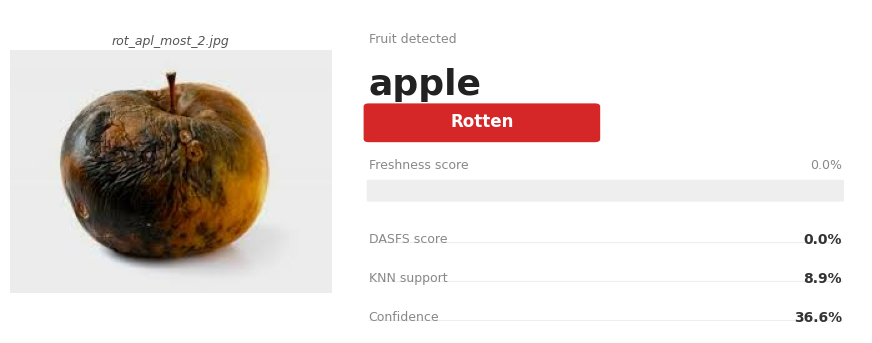

  Fruit     : apple
  Grade     : Rotten
  Score     : 0.0%
  Confidence: 36.6%
  Low-conf  : False


In [24]:
IMAGE_PATH = "test_img/rot_apl_most_2.jpg"   # <- change this

r   = predict(IMAGE_PATH)
img = cv2.imread(IMAGE_PATH)
lc  = {"Very Fresh": "#0bf30b", "Fresh": "#74c02e",
        "Slightly Degraded": "#fd8d3c", "Rotten": "#d62728"}.get(r["label"], "#888")

fig = plt.figure(figsize=(11, 4.2), facecolor="white")
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1.6], wspace=0.04)

ax_img = fig.add_subplot(gs[0])
ax_img.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax_img.axis("off")
ax_img.set_title(Path(IMAGE_PATH).name, fontsize=9,
                 color="#555", pad=4, style="italic")

ax = fig.add_subplot(gs[1])
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.text(0.04, 0.93, "Fruit detected", fontsize=9, color="#888", va="top")
ax.text(0.04, 0.82, r["fruit"], fontsize=26, fontweight="bold", color="#222", va="top")
if r["low_conf_flag"]:
    ax.text(0.04, 0.74, "! low-confidence routing",
            fontsize=8, color="#e67e00", va="top")
ax.add_patch(mpatches.FancyBboxPatch(
    (0.04, 0.60), 0.44, 0.10, boxstyle="round,pad=0.01",
    linewidth=0, facecolor=lc, transform=ax.transAxes, clip_on=False))
ax.text(0.26, 0.655, r["label"], fontsize=12, fontweight="bold", color="white",
        ha="center", va="center", transform=ax.transAxes)

fr = r["freshness_score"]
ax.text(0.04, 0.54, "Freshness score", fontsize=9, color="#888", va="top")
ax.text(0.96, 0.54, f"{fr:.1f}%",      fontsize=9, color="#888", va="top", ha="right")
ax.add_patch(mpatches.FancyBboxPatch(
    (0.04, 0.41), 0.92, 0.06, boxstyle="round,pad=0.004",
    linewidth=0, facecolor="#eee", transform=ax.transAxes, clip_on=False))
if fr > 2:
    ax.add_patch(mpatches.FancyBboxPatch(
        (0.04, 0.41), 0.92 * (fr / 100), 0.06, boxstyle="round,pad=0.004",
        linewidth=0, facecolor=lc, transform=ax.transAxes, clip_on=False))

for i, (k, v) in enumerate([("DASFS score", f"{r['dasfs_score']:.1f}%"),
                              ("KNN support", f"{r['knn_support']:.1f}%"),
                              ("Confidence",  f"{r['confidence']:.1f}%")]):
    yp = 0.31 - i * 0.12
    ax.text(0.04, yp, k, fontsize=9, color="#888", va="top")
    ax.text(0.96, yp, v, fontsize=10, fontweight="bold", color="#333",
            ha="right", va="top")
    ax.axhline(yp - 0.03, xmin=0.04, xmax=0.96, color="#eee", linewidth=0.8)

plt.tight_layout(pad=0.5); plt.show()
print(f"  Fruit     : {r['fruit']}")
print(f"  Grade     : {r['label']}")
print(f"  Score     : {r['freshness_score']}%")
print(f"  Confidence: {r['confidence']}%")
print(f"  Low-conf  : {r['low_conf_flag']}")


## Batch prediction — all images in `TEST_FOLDER`

Predict every image in `test_img/` at once.  
Outputs: summary table, per-fruit breakdown, colour-coded bar chart.


In [20]:
# ── Collect all image paths ───────────────────────────────────────────────────
batch_paths = sorted([
    p for p in Path(TEST_FOLDER).rglob("*")
    if p.suffix.lower() in EXTS
])

if not batch_paths:
    print(f"No images found in '{TEST_FOLDER}/'. "
          "Add images or change TEST_FOLDER at the top of the notebook.")
else:
    print(f"Found {len(batch_paths)} images in '{TEST_FOLDER}/'. Predicting...\n")
    batch_results = []
    for p in batch_paths:
        try:
            r = predict(str(p))
            r["filename"] = p.name
            batch_results.append(r)
        except Exception as e:
            print(f"  ERROR {p.name}: {e}")

    # ── Summary table ─────────────────────────────────────────────────────────
    print(f"{'FILE':<38} {'FRUIT':<14} {'LABEL':<20} "
          f"{'SCORE':>7}  {'CONF':>6}  {'LOW?':>4}")
    print("-" * 96)
    for r in batch_results:
        flag = "!" if r["low_conf_flag"] else ""
        print(f"  {r['filename']:<36} {r['fruit']:<14} {r['label']:<20} "
              f"{r['freshness_score']:>6.1f}%  {r['confidence']:>5.1f}%  {flag:>4}")

    # ── Per-fruit breakdown ────────────────────────────────────────────────────
    print("\n" + "=" * 55)
    print("Per-fruit summary")
    print("=" * 55)
    groups = defaultdict(list)
    for r in batch_results:
        groups[r["fruit"]].append(r)
    for fruit, items in sorted(groups.items()):
        sc = [x["freshness_score"] for x in items]
        lb = [x["label"] for x in items]
        print(f"  {fruit:15s}  N={len(items):3d}  "
              f"mean={float(np.mean(sc)):5.1f}%  "
              f"min={min(sc):5.1f}%  max={max(sc):5.1f}%")
        for lbl in ["Very Fresh", "Fresh", "Slightly Degraded", "Rotten"]:
            n = lb.count(lbl)
            if n:
                print(f"      {lbl:<22}: {n}")


Found 24 images in 'test_img/'. Predicting...

FILE                                   FRUIT          LABEL                  SCORE    CONF  LOW?
------------------------------------------------------------------------------------------------
  fre_cap.jpg                          capsicum       Slightly Degraded      35.7%   10.8%      
  fre_cap_sin.webp                     capsicum       Fresh                  66.6%   14.9%      
  fre_cap_single.jpg                   apple          Very Fresh            100.0%   56.3%     !
  fresh_banana.png                     banana         Very Fresh            100.0%   48.1%      
  fresh_banana_green.jpg               banana         Very Fresh             96.6%   45.4%      
  fresh_capsicum.jpg                   capsicum       Slightly Degraded      48.1%    4.6%      
  fresh_cucumber.jpg                   cucumber       Very Fresh             83.8%   27.4%      
  fresh_cucumber2.jpg                  cucumber       Fresh                  66.

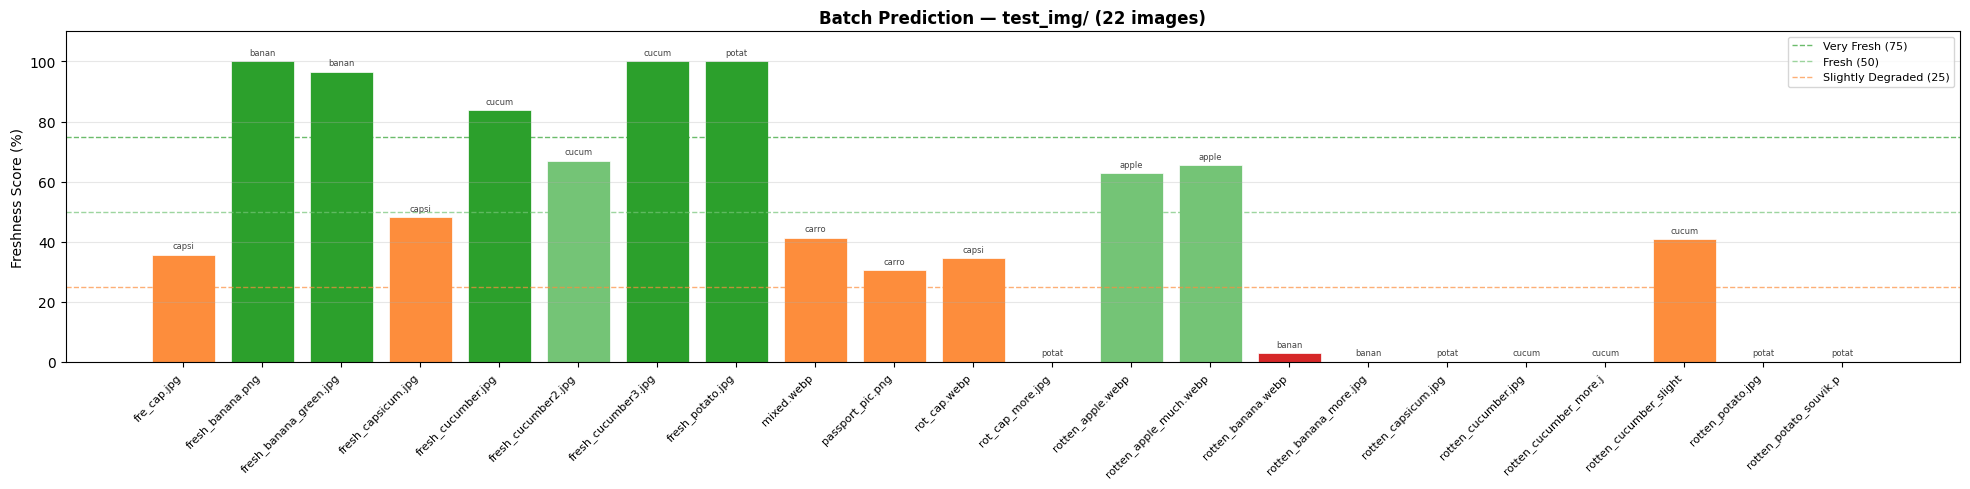

Saved -> pipeline_v2/artifacts/plot_batch_prediction.png


In [10]:
# ── Batch bar chart ───────────────────────────────────────────────────────────
if batch_results:
    color_map = {"Very Fresh": "#2ca02c", "Fresh": "#74c476",
                 "Slightly Degraded": "#fd8d3c", "Rotten": "#d62728",
                 "Unknown": "#888888"}
    names  = [r["filename"][:22] for r in batch_results]
    scores = [r["freshness_score"] for r in batch_results]
    colors = [color_map.get(r["label"], "#888") for r in batch_results]

    fig, ax = plt.subplots(figsize=(max(10, len(batch_results) * 0.9), 5))
    ax.bar(range(len(batch_results)), scores, color=colors,
           edgecolor="white", linewidth=0.5)
    for thresh, clr, lbl in [(75, "#2ca02c", "Very Fresh (75)"),
                              (50, "#74c476", "Fresh (50)"),
                              (25, "#fd8d3c", "Slightly Degraded (25)")]:
        ax.axhline(thresh, color=clr, ls="--", lw=1, alpha=0.7, label=lbl)
    ax.set_xticks(range(len(batch_results)))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 110); ax.set_ylabel("Freshness Score (%)")
    ax.set_title(f"Batch Prediction — {TEST_FOLDER}/ ({len(batch_results)} images)",
                 fontweight="bold")
    ax.legend(fontsize=8, loc="upper right"); ax.grid(axis="y", alpha=0.3)
    for i, r in enumerate(batch_results):
        ax.text(i, scores[i] + 1.5, r["fruit"][:5],
                ha="center", va="bottom", fontsize=6, color="#444")
    plt.tight_layout()
    out = f"{PIPELINE_DIR}/artifacts/plot_batch_prediction.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show(); print(f"Saved -> {out}")
